For motivation, watch the following video: https://www.youtube.com/watch?v=aircAruvnKk

To play with a network and visualize what's happening, check out: https://playground.tensorflow.org/

More visualization and justification of why initialization: https://www.deeplearning.ai/ai-notes/initialization/index.html

A topological explanation and visualization of neural networks: https://colah.github.io/posts/2014-03-NN-Manifolds-Topology/






##  Import Necessary Libraries

We need to import PyTorch, some submodules like `nn` for neural networks, `optim` for optimizers, and `DataLoader` for efficient data loading.


In [1]:

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms



## Load and Preprocess the Dataset

We will load the MNIST dataset using `torchvision.datasets`, apply transformations such as converting images to tensors, and normalize the pixel values between -1 and 1 using `transforms.Normalize`.


In [2]:

# Transform to convert images to tensor and normalize pixel values
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])

# Download and load the MNIST dataset
mnist_data = datasets.MNIST(root='./data', train=True, download=True, transform=transform)

# Split the dataset into train, dev, and test sets
train_size = int(0.8 * len(mnist_data))  # 80% for training
dev_size = int(0.1 * len(mnist_data))  # 10% for validation (dev)
test_size = len(mnist_data) - train_size - dev_size  # Remaining 10% for testing

train_data, dev_data, test_data = random_split(mnist_data, [train_size, dev_size, test_size])



## Use DataLoader for Efficient Data Loading

We will use PyTorch's `DataLoader` to load data in batches, which makes training more efficient and allows us to shuffle the training data.


In [3]:

batch_size = 64

# Create DataLoader for train, dev, and test sets
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
dev_loader = DataLoader(dev_data, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)



##  Define the Neural Network

We'll define a simple feedforward neural network with one hidden layer using PyTorch's `nn.Module`.


In [4]:

class SimpleNN(nn.Module):
    def __init__(self):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(28 * 28, 128)  # Input layer (28x28 pixels)
        self.fc2 = nn.Linear(128, 64)  # Hidden layer
        self.fc3 = nn.Linear(64, 10)  # Output layer (10 digits)

    def forward(self, x):
        x = x.view(-1, 28 * 28)  # Flatten the image to a vector of 28x28
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x



##  Define Loss and Optimizer

We will use **cross-entropy loss** for classification and **SGD (Stochastic Gradient Descent)** as the optimizer.


In [5]:

# Instantiate the model, loss function, and optimizer
model = SimpleNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)



##  Train the Network

We will train the model over multiple epochs, performing forward and backward passes, updating weights, and tracking the loss.


In [6]:

# Training loop
epochs = 20

for epoch in range(epochs):
    model.train()  # Set the model to training mode
    running_loss = 0

    for images, labels in train_loader:
        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass and optimize
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    # Print loss for the epoch
    print(f'Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(train_loader):.4f}')


Epoch [1/20], Loss: 1.1366
Epoch [2/20], Loss: 0.4268
Epoch [3/20], Loss: 0.3452
Epoch [4/20], Loss: 0.3106
Epoch [5/20], Loss: 0.2860
Epoch [6/20], Loss: 0.2662
Epoch [7/20], Loss: 0.2497
Epoch [8/20], Loss: 0.2340
Epoch [9/20], Loss: 0.2204
Epoch [10/20], Loss: 0.2072
Epoch [11/20], Loss: 0.1957
Epoch [12/20], Loss: 0.1855
Epoch [13/20], Loss: 0.1754
Epoch [14/20], Loss: 0.1670
Epoch [15/20], Loss: 0.1584
Epoch [16/20], Loss: 0.1504
Epoch [17/20], Loss: 0.1438
Epoch [18/20], Loss: 0.1366
Epoch [19/20], Loss: 0.1306
Epoch [20/20], Loss: 0.1254



##  Evaluate the Model on the Validation Set

After each epoch, we will evaluate the model on the validation (dev) set to track its accuracy.


In [7]:
import torch.nn.functional as F

def evaluate_model(loader):
    model.eval()  # Set the model to evaluation mode
    total, correct = 0, 0
    with torch.no_grad():  # Disable gradient calculation
        for images, labels in loader:
            outputs = model(images)
            probabilities = F.softmax(outputs, dim=1)
            predicted = torch.argmax(probabilities, dim=1)            
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return correct / total

# Evaluate on dev set
accuracy = evaluate_model(dev_loader)
print(f'Validation Accuracy: {accuracy * 100:.2f}%')


Validation Accuracy: 95.85%



##  Test the Model

Finally, after training and validating the model, we evaluate it on the test set to see its generalization performance.


In [8]:

# Evaluate on test set
test_accuracy = evaluate_model(test_loader)
print(f'Test Accuracy: {test_accuracy * 100:.2f}%')


Test Accuracy: 95.37%


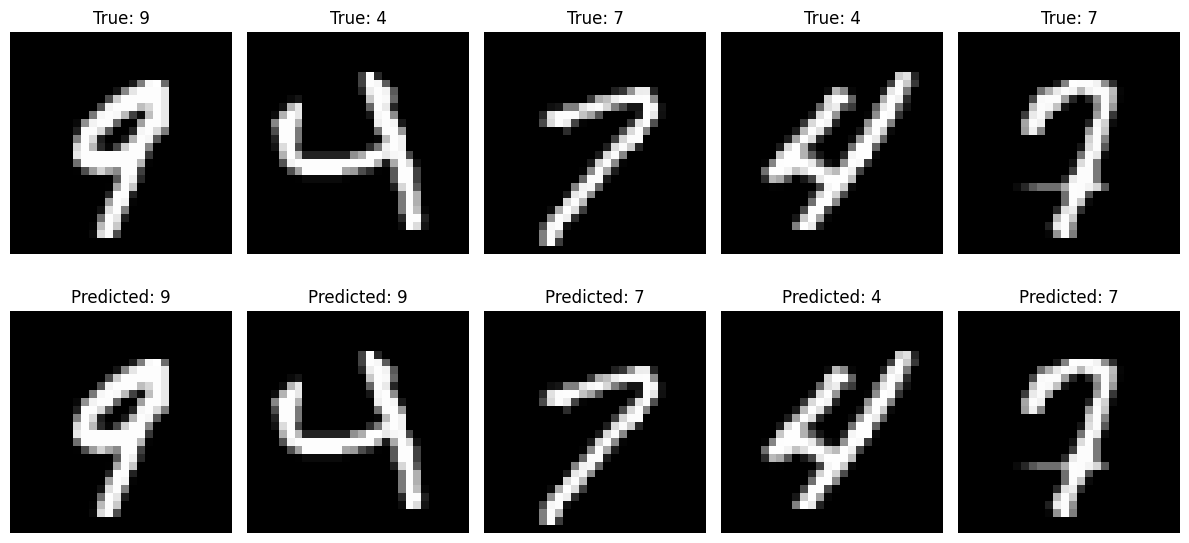

In [9]:
import matplotlib.pyplot as plt
import torch.nn.functional as F

# Function to visualize a few examples before and after training
def visualize_examples(model, data_loader, num_examples=5):
    model.eval()  # Set the model to evaluation mode
    examples_shown = 0
    
    fig, axes = plt.subplots(2, num_examples, figsize=(12, 6))  # 2 rows: before and after training
    
    # Iterate through the data
    with torch.no_grad():
        for images, labels in data_loader:
            # Show the first few examples
            if examples_shown >= num_examples:
                break
            
            for i in range(len(images)):
                if examples_shown >= num_examples:
                    break
                
                image = images[i].squeeze()  # Get the image
                label = labels[i].item()  # True label
                
                # Predict the label before training
                outputs = model(images[i].unsqueeze(0))  # Add batch dimension
                probabilities = F.softmax(outputs, dim=1)  # Apply softmax
                predicted_label = torch.argmax(probabilities, dim=1).item()  # Argmax to get predicted class

                # Visualize the image
                axes[0, examples_shown].imshow(image, cmap='gray')
                axes[0, examples_shown].set_title(f"True: {label}")
                axes[0, examples_shown].axis('off')

                # Visualize the predicted label after training
                axes[1, examples_shown].imshow(image, cmap='gray')
                axes[1, examples_shown].set_title(f"Predicted: {predicted_label}")
                axes[1, examples_shown].axis('off')
                
                examples_shown += 1
    
    plt.tight_layout()
    plt.show()

# Visualize 5 examples after training
visualize_examples(model, test_loader, num_examples=5)